In [ ]:
pip install pystac-client requests

In [ ]:
pip install boto3 requests

In [ ]:
import uuid
import requests
import boto3
from pystac_client import Client
import datacube
from datacube.utils import documents
from datetime import datetime, timedelta, timezone
from datacube.model import Dataset
from datacube.index.hl import Doc2Dataset
from datacube.utils.geometry import Geometry
# ==========================================
# 1. CẤU HÌNH HỆ THỐNG
# ==========================================
MINIO_ENDPOINT = "http://minio:9000"
MINIO_ACCESS_KEY = "minioadmin"
MINIO_SECRET_KEY = "minioadmin123"
BUCKET_NAME = "odc-data"

s3_client = boto3.client(
    's3',
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
    region_name='local'
)

# ---------------------------------------------------------
# BẢNG ÁNH XẠ: Tên Band trong Product YAML <--> Tên Asset trên AWS STAC
# ---------------------------------------------------------
BAND_MAPPING = {
    "blue": "blue",
    "green": "green",
    "red": "red",
    "nir": "nir",
    "red_edge_1": "rededge1",
    "red_edge_2": "rededge2",
    "red_edge_3": "rededge3",
    "nir_narrow": "nir08",
    "swir_1": "swir16",
    "swir_2": "swir22",
    "coastal_aerosol": "coastal",
    "water_vapour": "nir09",
    "SCL": "scl",
    "AOT": "aot",
    "WVP": "wvp"
}

# ==========================================
# GIAI ĐOẠN 1: TRUY VẤN DỮ LIỆU TỪ AWS
# ==========================================
def search_sentinel2_aws():
    stac_url = "https://earth-search.aws.element84.com/v1"
    catalog = Client.open(stac_url)
    
    today = datetime.now()
    past_date = today - timedelta(days=90) 
    time_range = f"{past_date.strftime('%Y-%m-%d')}/{today.strftime('%Y-%m-%d')}"
    cantho_bbox = [105.22, 9.91, 105.84, 10.32] # bounding box need to find
    
    print(f"🔎 Đang tìm ảnh Sentinel-2 từ {time_range} với mây < 60%...")
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=cantho_bbox,
        datetime=time_range,
        query={"eo:cloud_cover": {"lt": 60}} 
    )
    
    items = list(search.items())
    if not items:
        return None
        
    items.sort(key=lambda x: x.properties.get('eo:cloud_cover', 100))
    return items[0]

# ==========================================
# GIAI ĐOẠN 2: BƠM DỮ LIỆU SANG MINIO
# ==========================================
def stream_to_minio(download_url, object_name):
    with requests.get(download_url, stream=True) as response:
        response.raise_for_status()
        s3_client.upload_fileobj(response.raw, BUCKET_NAME, object_name)

# ==========================================
# GIAI ĐOẠN 3: ĐỒNG BỘ CẤU TRÚC ĐỊNH DẠNG DATASET (EO3)
# ==========================================
def build_odc_dataset_metadata(stac_item, bucket_name):
    print("📝 Đang khởi tạo luồng dịch cấu trúc siêu dữ liệu (Data Mapping)...")
    
    item_id = stac_item.id
    date_str = stac_item.properties['datetime'][:10]
    dataset_id = str(uuid.uuid5(uuid.NAMESPACE_DNS, item_id))
    
    epsg_code = stac_item.properties.get('proj:epsg', 32648)
    crs_str = f"EPSG:{epsg_code}"

    geom_4326 = Geometry(stac_item.geometry, crs="EPSG:4326")
    geom_projected = geom_4326.to_crs(crs_str)
    
    red_asset = stac_item.assets.get("red")
    if red_asset and 'proj:transform' in red_asset.extra_fields:
        proj_transform = red_asset.extra_fields['proj:transform']
        proj_shape = red_asset.extra_fields.get('proj:shape', [10980, 10980])
    else:
        proj_transform = stac_item.properties.get('proj:transform', [10.0, 0.0, 500000.0, 0.0, -10.0, 1100000.0])
        proj_shape = stac_item.properties.get('proj:shape', [10980, 10980])
    
    minio_base_url = f"s3://{bucket_name}/sentinel2/{date_str}/{item_id}"
    
    # Sinh động danh sách measurements dựa trên BAND_MAPPING
    measurements_dict = {}
    for odc_band_name, stac_asset_key in BAND_MAPPING.items():
        if stac_asset_key in stac_item.assets:
            measurements_dict[odc_band_name] = {"path": f"{minio_base_url}/{odc_band_name}.tif"}

    odc_dataset_doc = {
        "$schema": "https://schemas.opendatacube.org/dataset",
        "id": dataset_id,
        "product": {
            "name": "s2_l2a_cantho"
        },
        "crs": crs_str,
        "geometry": geom_projected.json,
        "grids": {
            "default": {
                "shape": proj_shape,
                "transform": proj_transform + [0, 0, 1] 
            }
        },
        "properties": {
            "datetime": stac_item.properties['datetime'],
            "odc:processing_datetime": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
            "eo:platform": "sentinel-2",
            "eo:instrument": "msi",
            "eo:cloud_cover": stac_item.properties.get('eo:cloud_cover', 0),
            "odc:processing_level": "l2a"
        },
        "measurements": measurements_dict,
        "lineage": {}
    }
    
    print("✅ Đã sinh cấu trúc siêu dữ liệu Dataset dạng Object Dictionary thành công!")
    return odc_dataset_doc

# ==========================================
# KHỐI THỰC THI CHÍNH CỦA ĐƯỜNG ỐNG DỮ LIỆU
# ==========================================
if __name__ == "__main__":
    best_item = search_sentinel2_aws()
    
    if best_item:
        item_id = best_item.id
        date_str = best_item.properties['datetime'][:10]
        print(f"🚀 Triển khai xử lý ảnh: {item_id}")
        
        # 1. Quét qua cấu hình BAND_MAPPING để tạo danh sách cần tải
        assets_to_download = {}
        for odc_band_name, stac_asset_key in BAND_MAPPING.items():
            if stac_asset_key in best_item.assets:
                # Đổi tên file khi lưu vào MinIO theo tên band của ODC cho đồng nhất
                assets_to_download[f"{odc_band_name}.tif"] = best_item.assets[stac_asset_key].href
            else:
                print(f"⚠️ Cảnh báo: Không tìm thấy asset '{stac_asset_key}' trên AWS STAC.")
        
        # 2. Truyền tải toàn bộ 15 bands sang MinIO
        for file_name, url in assets_to_download.items():
            minio_object_path = f"sentinel2/{date_str}/{item_id}/{file_name}"
            print(f"⬇️ Đang xử lý truyền dòng byte: {minio_object_path} ...", end=" ", flush=True)
            stream_to_minio(url, minio_object_path)
            print("✅")
            
        print("-" * 50)
        
        dataset_yaml_document = build_odc_dataset_metadata(best_item, BUCKET_NAME)
        
        print("\n=== Bản xem trước thông tin Khai sinh Dataset ===")
        print(f"ID cấp phát: {dataset_yaml_document['id']}")
        print(f"Tổng số bands đã xử lý: {len(dataset_yaml_document['measurements'])}")
        print("-" * 50)

        print("🚀 Bắt đầu Giai đoạn 4: Nạp hồ sơ vào Cơ sở dữ liệu PostGIS...")

        try:
            dc = datacube.Datacube(app="sentinel2-auto-ingest")
            resolver = Doc2Dataset(dc.index)
            dataset_uri = f"s3://{BUCKET_NAME}/sentinel2/{date_str}/{item_id}/dataset.yaml"
            
            odc_dataset, error = resolver(dataset_yaml_document, uri=dataset_uri)
    
            if error:
                print(f"❌ Lỗi kiểm tra cấu trúc dữ liệu (Validation Error): {error}")
            else:
                dc.index.datasets.add(odc_dataset)
                print(f"🎉 THÀNH CÔNG RỰC RỠ! Dataset ID {dataset_yaml_document['id']} đã được lưu vĩnh viễn vào PostGIS.")
                print("Hệ thống PostGIS đã lập chỉ mục không gian xong. Bản đồ sẵn sàng hiển thị trên Explorer web!")

        except Exception as e:
            print(f"❌ Lỗi hệ thống khi nạp vào cơ sở dữ liệu: {e}")

Đang quét và tải TOÀN BỘ 15 bands vào RAM...
✅ Tìm thấy 1 bức ảnh. Đã nạp thành công 15 bands.
Đang vẽ ma trận 15 bands cho ngày: 2026-03-25


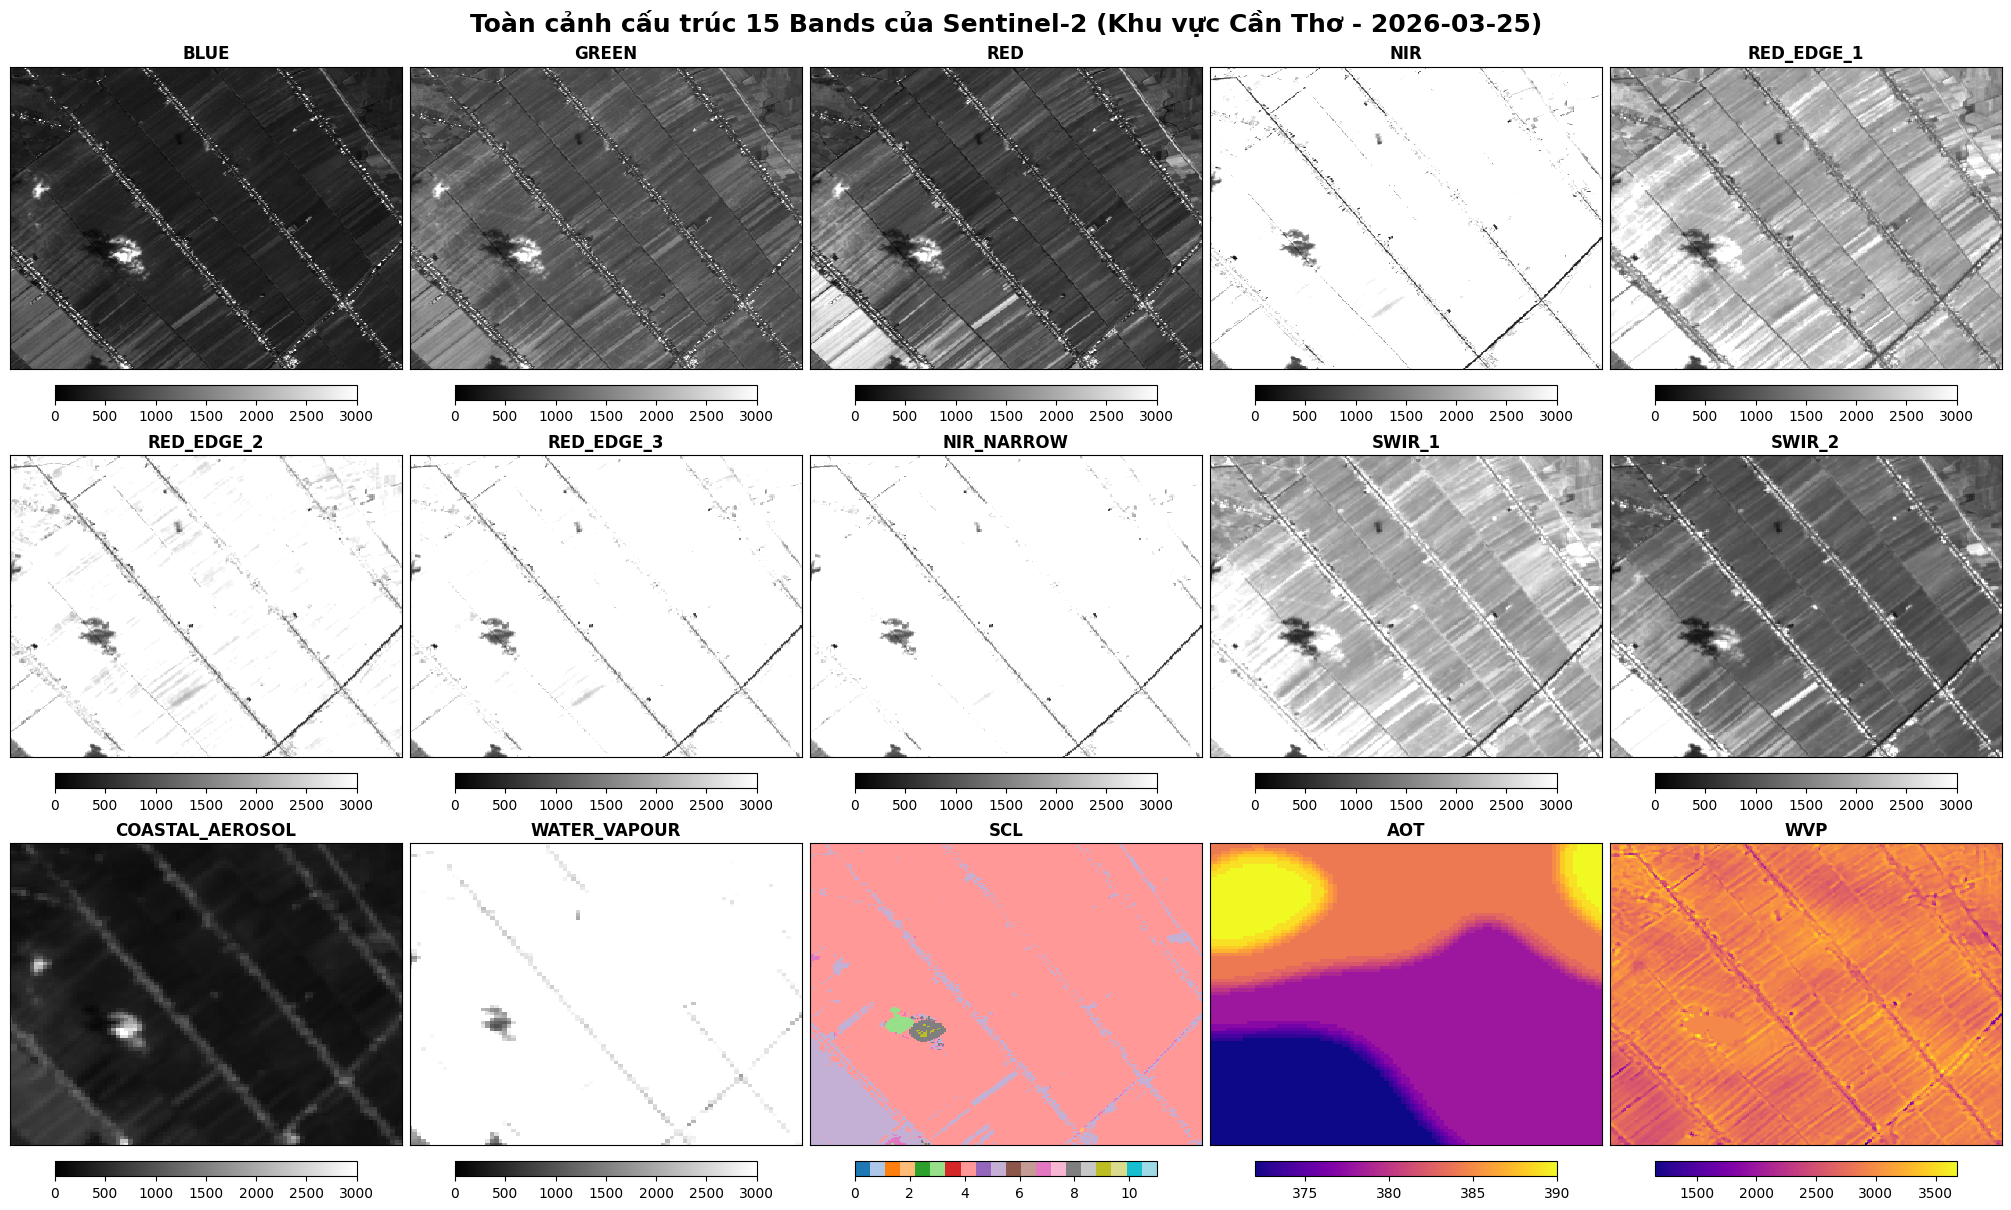

In [2]:
import os
import numpy as np
import datacube
import matplotlib.pyplot as plt

# ==============================================================
# CẤU HÌNH KẾT NỐI MINIO NỘI BỘ 
# ==============================================================
for key in list(os.environ.keys()):
    if key.startswith("AWS_") or key.startswith("S3_") or key.startswith("GDAL_"):
        del os.environ[key]

os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin123"
os.environ["AWS_S3_ENDPOINT"] = "minio:9000"  # Hoặc localhost:9000
os.environ["AWS_REGION"] = "local"
os.environ["AWS_HTTPS"] = "NO"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["S3_USE_HTTPS"] = "0"
os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR"
# ==============================================================

dc = datacube.Datacube(app="sentinel2_all_bands_display")

# query = {
#     'lon': (105.75, 105.80), # Thu nhỏ bề ngang
#     'lat': (10.00, 10.05),   # Thu nhỏ bề dọc
#     'time': ('2026-01-01', '2026-12-31')
# }

query = {
    'lon': (105.28, 105.33), 
    'lat': (10.22, 10.27),   
    'time': ('2026-01-01', '2026-12-31')
}

# Khai báo chính xác 15 bands đã định nghĩa trong file product YAML
all_bands = [
    'blue', 'green', 'red', 'nir', 
    'red_edge_1', 'red_edge_2', 'red_edge_3', 'nir_narrow', 
    'swir_1', 'swir_2', 'coastal_aerosol', 'water_vapour', 
    'SCL', 'AOT', 'WVP'
]

print("Đang quét và tải TOÀN BỘ 15 bands vào RAM...")

ds = dc.load(
    product='s2_l2a_cantho',
    measurements=all_bands,
    crs='EPSG:4326', # <--- QUAN TRỌNG: Khai báo hệ tọa độ của cục query bên trên
    output_crs='EPSG:4326', # Hệ tọa độ đầu ra mong muốn
    resolution=(-0.0001, 0.0001), 
    **query
)

if 'time' in ds.dims:
    num_scenes = ds.time.size
    print(f"✅ Tìm thấy {num_scenes} bức ảnh. Đã nạp thành công {len(list(ds.data_vars))} bands.")
    
    # Để đồ thị dễ nhìn, ta lấy bức ảnh đầu tiên (index = 0) để show full 15 bands
    scene = ds.isel(time=0)
    date_str = str(scene.time.values)[:10]
    
    print(f"Đang vẽ ma trận 15 bands cho ngày: {date_str}")

    # Tạo lưới biểu đồ 3 hàng x 5 cột = 15 ô
    fig, axes = plt.subplots(3, 5, figsize=(20, 12), constrained_layout=True)
    axes = axes.flatten() # Trải phẳng mảng axes 2D thành 1D để dễ lặp

    for idx, band_name in enumerate(all_bands):
        ax = axes[idx]
        band_data = scene[band_name]
        
        # Tùy chỉnh màu sắc hiển thị dựa trên tính chất của từng band
        if band_name == 'SCL':
            # Lớp phân loại (Category) từ 0-11
            im = band_data.plot(ax=ax, cmap='tab20', vmin=0, vmax=11, add_colorbar=False)
        elif band_name in ['AOT', 'WVP']:
            # Lớp tham số khí quyển (Khói bụi, Hơi nước)
            im = band_data.plot(ax=ax, cmap='plasma', add_colorbar=False)
        else:
            # Các dải quang học (Dùng thang xám để phân tích cường độ phản xạ gốc)
            im = band_data.plot(ax=ax, cmap='gray', vmin=0, vmax=3000, add_colorbar=False)
            
        # Thêm thanh màu (colorbar) nhỏ bên dưới mỗi ảnh
        fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, fraction=0.05)
            
        # Trang trí label
        ax.set_title(band_name.upper(), fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('')
        # Tắt tọa độ chi tiết để ma trận nhìn thoáng hơn
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"Toàn cảnh cấu trúc 15 Bands của Sentinel-2 (Khu vực Cần Thơ - {date_str})", fontsize=18, fontweight='bold')
    plt.show()

else:
    print("❌ Không tìm thấy dữ liệu nào.")

Đang quét và tải dải Red và NIR vào RAM...
✅ Tìm thấy dữ liệu. Bắt đầu tính toán NDVI...
🎨 Đang kết xuất sơ đồ...
✅ Sơ đồ NDVI (masked) đã hoàn thiện!


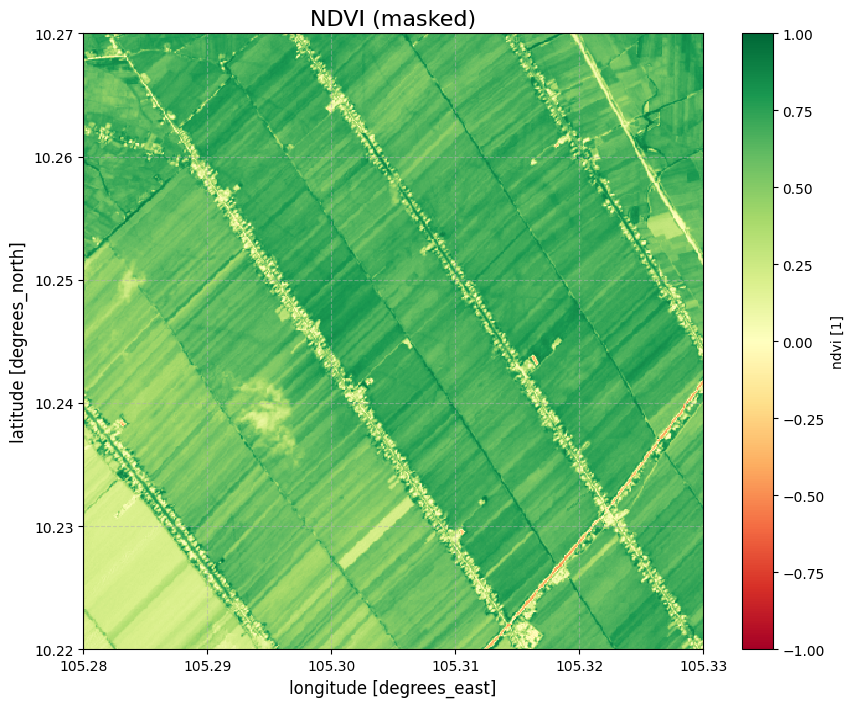

In [3]:
import os
import numpy as np
import datacube
import matplotlib.pyplot as plt

# ==============================================================
# 1. CẤU HÌNH KẾT NỐI MINIO NỘI BỘ 
# ==============================================================
for key in list(os.environ.keys()):
    if key.startswith("AWS_") or key.startswith("S3_") or key.startswith("GDAL_"):
        del os.environ[key]

os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin123"
os.environ["AWS_S3_ENDPOINT"] = "minio:9000"  # Hoặc localhost:9000
os.environ["AWS_REGION"] = "local"
os.environ["AWS_HTTPS"] = "NO"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["S3_USE_HTTPS"] = "0"
os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR"

# ==============================================================
# 2. KHỞI TẠO DATACUBE VÀ THIẾT LẬP TRUY VẤN
# ==============================================================
dc = datacube.Datacube(app="sentinel2_ndvi_standalone")

# Sử dụng vùng không gian đã thu nhỏ để đảm bảo không bị tràn RAM
# query = {
#     'lon': (105.75, 105.80), 
#     'lat': (10.00, 10.05),   
#     'time': ('2026-01-01', '2026-12-31')
# }

query = {
    'lon': (105.28, 105.33), 
    'lat': (10.22, 10.27),   
    'time': ('2026-01-01', '2026-12-31')
}

print("Đang quét và tải dải Red và NIR vào RAM...")

# Chỉ tải 2 dải phổ cần thiết để tối ưu bộ nhớ
ds = dc.load(
    product='s2_l2a_cantho',
    measurements=['red', 'nir'], 
    crs='EPSG:4326', 
    output_crs='EPSG:4326', 
    resolution=(-0.0001, 0.0001), 
    **query
)

# ==============================================================
# 3. TÍNH TOÁN VÀ HIỂN THỊ NDVI
# ==============================================================
if 'time' in ds.dims:
    print("✅ Tìm thấy dữ liệu. Bắt đầu tính toán NDVI...")
    
    # Lấy bức ảnh đầu tiên
    scene = ds.isel(time=0)
    
    # Ép kiểu float để thực hiện phép chia thập phân
    red = scene.red.astype(float)
    nir = scene.nir.astype(float)
    
    # Tính toán NDVI: (NIR - RED) / (NIR + RED)
    ndvi = (nir - red) / (nir + red)
    
    # Xử lý masking: Tìm các điểm pixel bị lỗi chia cho 0 (khi nir + red == 0)
    nodata_mask = (nir + red == 0)
    
    # Loại bỏ nhiễu và kẹp dải giá trị từ -1.0 đến 1.0 chuẩn NDVI
    ndvi_masked = ndvi.where(~nodata_mask).clip(-1.0, 1.0)
    
    # Vẽ biểu đồ
    print("🎨 Đang kết xuất sơ đồ...")
    plt.figure(figsize=(10, 8))
    
    # Cấu hình màu sắc và thanh colorbar khớp với ảnh mục tiêu
    ndvi_plot = ndvi_masked.plot(
        cmap='RdYlGn',     
        vmin=-1.0,         
        vmax=1.0,          
        add_colorbar=True, 
        cbar_kwargs={'label': 'ndvi [1]'} 
    )
    
    # Thiết lập tiêu đề và nhãn trục (verbatim)
    plt.title('NDVI (masked)', fontsize=16)
    plt.xlabel('longitude [degrees_east]', fontsize=12)
    plt.ylabel('latitude [degrees_north]', fontsize=12)
    
    # Bật lưới đứt nét để dễ căn chỉnh tọa độ
    plt.grid(True, linestyle='--', alpha=0.5)
    
    print("✅ Sơ đồ NDVI (masked) đã hoàn thiện!")
    plt.show()

else:
    print("❌ Không tìm thấy dữ liệu nào thỏa mãn điều kiện truy vấn.")

Đang quét và tải dải Red, Green và Blue vào RAM...
✅ Tìm thấy dữ liệu. Bắt đầu xử lý ảnh RGB...
🎨 Đang kết xuất ảnh Màu thực...
✅ Ảnh True Color đã hoàn thiện!


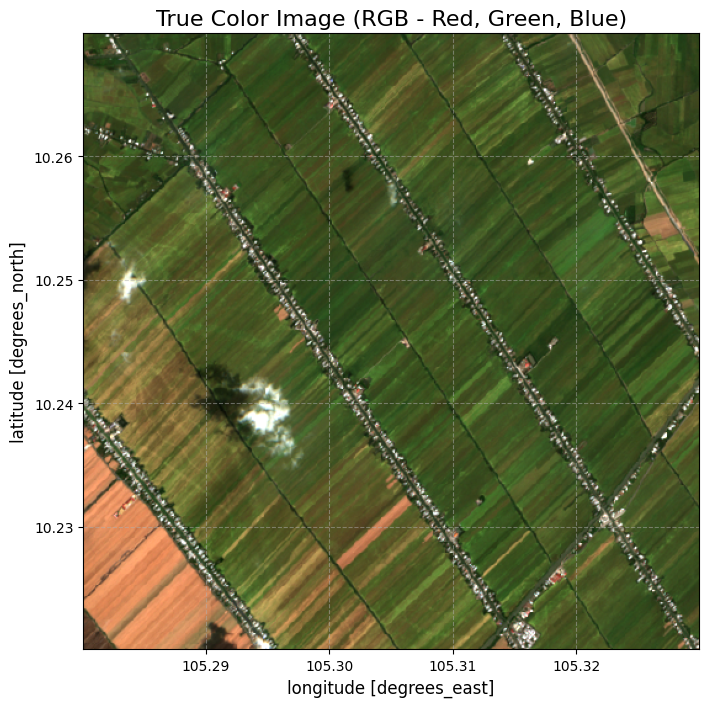

In [4]:
import os
import numpy as np
import datacube
import matplotlib.pyplot as plt

# ==============================================================
# 1. CẤU HÌNH KẾT NỐI MINIO NỘI BỘ 
# ==============================================================
for key in list(os.environ.keys()):
    if key.startswith("AWS_") or key.startswith("S3_") or key.startswith("GDAL_"):
        del os.environ[key]

os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin123"
os.environ["AWS_S3_ENDPOINT"] = "minio:9000"  # Hoặc localhost:9000
os.environ["AWS_REGION"] = "local"
os.environ["AWS_HTTPS"] = "NO"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["S3_USE_HTTPS"] = "0"
os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR"

# ==============================================================
# 2. KHỞI TẠO DATACUBE VÀ THIẾT LẬP TRUY VẤN
# ==============================================================
dc = datacube.Datacube(app="sentinel2_rgb_standalone")

query = {
    'lon': (105.28, 105.33), 
    'lat': (10.22, 10.27),   
    'time': ('2026-01-01', '2026-12-31')
}

print("Đang quét và tải dải Red, Green và Blue vào RAM...")

# Tải 3 dải phổ để tạo ảnh màu thực
ds = dc.load(
    product='s2_l2a_cantho',
    measurements=['red', 'green', 'blue'], 
    crs='EPSG:4326', 
    output_crs='EPSG:4326', 
    resolution=(-0.0001, 0.0001), 
    **query
)

# ==============================================================
# 3. XỬ LÝ VÀ HIỂN THỊ ẢNH RGB
# ==============================================================
if 'time' in ds.dims:
    print("✅ Tìm thấy dữ liệu. Bắt đầu xử lý ảnh RGB...")
    
    # Lấy bức ảnh đầu tiên
    scene = ds.isel(time=0)
    
    # Trích xuất ma trận giá trị và ép kiểu float
    r = scene.red.values.astype(float)
    g = scene.green.values.astype(float)
    b = scene.blue.values.astype(float)
    
    # Gộp 3 dải thành một khối ma trận 3D (Chiều cao x Chiều rộng x 3 kênh màu)
    rgb_stack = np.dstack((r, g, b))
    
    # Chuẩn hóa dải giá trị quang phổ (0 - ~10000) về chuẩn hiển thị của Matplotlib (0.0 - 1.0)
    # Chia cho 3000 là một kỹ thuật tiêu chuẩn để ảnh sáng và rõ nét, không bị tối đen
    rgb_scaled = np.clip(rgb_stack / 3000.0, 0, 1)
    
    # Lấy giới hạn tọa độ không gian để gán lên trục tọa độ
    extent = [
        float(scene.longitude.min()), float(scene.longitude.max()),
        float(scene.latitude.min()), float(scene.latitude.max())
    ]
    
    # Vẽ biểu đồ
    print("🎨 Đang kết xuất ảnh Màu thực...")
    plt.figure(figsize=(10, 8))
    
    # Hiển thị ảnh RGB
    plt.imshow(rgb_scaled, extent=extent)
    
    # Thiết lập tiêu đề và nhãn trục
    plt.title('True Color Image (RGB - Red, Green, Blue)', fontsize=16)
    plt.xlabel('longitude [degrees_east]', fontsize=12)
    plt.ylabel('latitude [degrees_north]', fontsize=12)
    
    # Bật lưới đứt nét
    plt.grid(True, linestyle='--', alpha=0.5)
    
    print("✅ Ảnh True Color đã hoàn thiện!")
    plt.show()

else:
    print("❌ Không tìm thấy dữ liệu nào thỏa mãn điều kiện truy vấn.")